<a href="https://colab.research.google.com/github/AngeP02/MonteCarloPerRadioterapia/blob/main/Progetto_HPC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup ambiente di sviluppo

In [1]:
!nvidia-smi                    # che GPU hai
!nvcc --version                # versione CUDA
!gcc --version                 # compilatore C++
!python3 --version             # Python per i grafici
!pip install numpy matplotlib  # librerie plotting

Thu Apr  9 19:53:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Creazione della struttura delle celle

In [2]:
import os
os.makedirs('mc_rt_cpu', exist_ok=True)
print("Cartella creata")

Cartella creata


## Nuova sezione

# Versione CPU sequenziale

## Creazione risultati CPU sequenziale

In [19]:
%%writefile mc_rt_cpu/physics.h
#pragma once
#include <cmath>

// ─── Costanti fisiche ────────────────────────────────────────────────────────
static const float ME_C2    = 0.511f;   // massa elettrone in MeV
static const float ECUT     = 0.010f;   // cutoff energia fotoni (10 keV)
static const float VOXEL_CM = 0.30f;    // dimensione voxel in cm (3 mm)
static const int   NX = 100, NY = 100, NZ = 100;

// ─── Indici materiali ─────────────────────────────────────────────────────────
#define MAT_WATER  0
#define MAT_BONE   1
#define MAT_LUNG   2
#define MAT_AIR    3

// ─── Coefficienti di attenuazione totale a 2 MeV (cm^-1) ────────────────────
// Fonte: NIST XCOM, mu = (mu/rho) * rho
// Acqua:  mu/rho=0.04942 cm2/g * 1.000 g/cm3 = 0.04942 cm^-1
// Osso:   mu/rho=0.03036 cm2/g * 1.850 g/cm3 = 0.05617 cm^-1
// Polmone:mu/rho=0.04942 cm2/g * 0.260 g/cm3 = 0.01285 cm^-1
// Aria:   mu/rho=0.04000 cm2/g * 0.00120 g/cm3 = 0.000048 cm^-1
static const float MU_TOTAL[4]   = { 0.04942f, 0.05617f, 0.01285f, 0.000048f };

// Frazione Compton sul totale a 2 MeV
// A 2 MeV nei tessuti biologici il Compton domina (~96-98%)
// Fonte: NIST XCOM (rapporto mu_Compton / mu_total)
static const float P_COMPTON[4]  = { 0.970f,   0.910f,   0.970f,   0.970f   };

// ─── Restituisce mu totale per un materiale ───────────────────────────────────
inline float get_mu(int material) {
    if (material < 0 || material > 3) return MU_TOTAL[MAT_WATER];
    return MU_TOTAL[material];
}

// ─── Restituisce la probabilità Compton per un materiale ─────────────────────
inline float get_p_compton(int material) {
    if (material < 0 || material > 3) return P_COMPTON[MAT_WATER];
    return P_COMPTON[material];
}

// ─── Seleziona il tipo di interazione ────────────────────────────────────────
// Restituisce: 0=fotoelettrico, 1=Compton, 2=produzione coppie
inline int select_interaction(float xi, int material) {
    float pc = get_p_compton(material);
    // produzione coppie trascurabile a 2 MeV (soglia 1.022 MeV ma rara)
    // a 6 MV medio ~2 MeV: ~2% fotoelettrico, ~97% Compton, ~1% coppie
    if (xi < (1.0f - pc - 0.01f)) return 0;  // fotoelettrico
    if (xi < (1.0f - 0.01f))       return 1;  // Compton
    return 2;                                  // produzione coppie
}

Overwriting mc_rt_cpu/physics.h


In [20]:
%%writefile mc_rt_cpu/compton.h
#pragma once
#include <cmath>
#include "physics.h"

// ─── Campionamento Klein-Nishina con metodo di Kahn ──────────────────────────
// Fonte: Salvat et al., PENELOPE-2014, sezione 2.2, equazioni 2.36-2.52
// Restituisce cos(theta) dell'angolo di scattering Compton
// energy: energia del fotone incidente in MeV
// rng:    funzione che restituisce float uniforme in [0,1)
template<typename RNG>
inline float sample_compton_cos_theta(float energy, RNG& rng) {
    float alpha = energy / ME_C2;   // energia ridotta
    float alpha2 = 2.0f * alpha;

    float cos_theta, xi1, xi2, xi3;
    float g;  // funzione di test per accettazione

    // Metodo di Kahn: rejection sampling sulla Klein-Nishina
    // Si decompone la sezione d'urto in due componenti
    // e si campiona con accettazione/rifiuto
    int max_iter = 1000;
    for (int iter = 0; iter < max_iter; iter++) {
        xi1 = rng();
        xi2 = rng();
        xi3 = rng();

        if (xi1 * (2.0f + alpha2) < 2.0f) {
            // Componente 1: distribuzione uniforme in epsilon
            // epsilon = E'/E (rapporto energie)
            float epsilon = 1.0f / (1.0f + alpha2 * xi2);
            cos_theta = 1.0f - (1.0f - epsilon) / alpha;
            // Funzione di accettazione
            g = 1.0f - (epsilon * (1.0f - cos_theta * cos_theta)) /
                       (1.0f + epsilon * epsilon);
        } else {
            // Componente 2
            float epsilon = (1.0f + alpha2) / (1.0f + alpha2 * xi2);
            // epsilon qui può essere > 1, limita
            if (epsilon > (1.0f + alpha2)) epsilon = 1.0f + alpha2;
            cos_theta = 1.0f - (epsilon - 1.0f) / alpha;
            float sin2_theta = 1.0f - cos_theta * cos_theta;
            if (sin2_theta < 0.0f) sin2_theta = 0.0f;
            g = 0.5f * sin2_theta;
        }

        // Accetta se xi3 < g (g è già normalizzata in [0,1])
        if (xi3 < g) {
            // Clamp cos_theta in [-1, 1]
            if (cos_theta >  1.0f) cos_theta =  1.0f;
            if (cos_theta < -1.0f) cos_theta = -1.0f;
            return cos_theta;
        }
    }
    // Fallback (non dovrebbe accadere)
    return 0.0f;
}

// ─── Nuova energia del fotone dopo Compton ────────────────────────────────────
// Formula relativistica dalla conservazione di energia e quantità di moto
// Fonte: Attix, "Introduction to Radiological Physics", cap. 8
inline float compton_new_energy(float energy, float cos_theta) {
    return energy / (1.0f + (energy / ME_C2) * (1.0f - cos_theta));
}

// ─── Aggiorna la direzione del fotone dopo Compton ───────────────────────────
// Rotazione 3D della direzione (dx, dy, dz) di angolo theta attorno
// a un asse perpendicolare, con angolo azimutale phi casuale
// Fonte: Salvat PENELOPE-2014, appendice sulla rotazione di sistemi di riferimento
template<typename RNG>
inline void update_direction(float& dx, float& dy, float& dz,
                             float cos_theta, RNG& rng) {
    float sin_theta = sqrtf(fmaxf(0.0f, 1.0f - cos_theta * cos_theta));
    float phi = 2.0f * 3.14159265f * rng();
    float cos_phi = cosf(phi);
    float sin_phi = sinf(phi);

    // Calcola nuovo sistema di riferimento
    // Se dz è vicino a ±1, usa asse alternativo per evitare singolarità
    float dx_new, dy_new, dz_new;

    if (fabsf(dz) < 0.9999f) {
        float norm_xy = sqrtf(1.0f - dz * dz);
        dx_new = sin_theta * (dx * dz * cos_phi - dy * sin_phi) / norm_xy
                 + dx * cos_theta;
        dy_new = sin_theta * (dy * dz * cos_phi + dx * sin_phi) / norm_xy
                 + dy * cos_theta;
        dz_new = -sin_theta * cos_phi * norm_xy + dz * cos_theta;
    } else {
        // Caso degenere: fotone lungo asse Z
        float sign_z = (dz > 0.0f) ? 1.0f : -1.0f;
        dx_new = sin_theta * cos_phi;
        dy_new = sin_theta * sin_phi * sign_z;
        dz_new = cos_theta * sign_z;
    }

    // Normalizza per sicurezza numerica
    float norm = sqrtf(dx_new*dx_new + dy_new*dy_new + dz_new*dz_new);
    if (norm > 0.0f) { dx = dx_new/norm; dy = dy_new/norm; dz = dz_new/norm; }
}

Overwriting mc_rt_cpu/compton.h


In [21]:
%%writefile mc_rt_cpu/geometry.h
#pragma once
#include <cmath>
#include "physics.h"

// ─── Phantom: array lineare 3D ───────────────────────────────────────────────
// Layout: index = ix + NX*(iy + NY*iz)  → X varia più veloce
inline int phantom_index(int ix, int iy, int iz) {
    return ix + NX * (iy + NY * iz);
}

// ─── Verifica se la particella è dentro il phantom ───────────────────────────
inline bool inside_phantom(float x, float y, float z) {
    return x >= 0.0f && x < NX * VOXEL_CM &&
           y >= 0.0f && y < NY * VOXEL_CM &&
           z >= 0.0f && z < NZ * VOXEL_CM;
}

// ─── Indici del voxel corrente ───────────────────────────────────────────────
inline int vox_x(float x) { return (int)(x / VOXEL_CM); }
inline int vox_y(float y) { return (int)(y / VOXEL_CM); }
inline int vox_z(float z) { return (int)(z / VOXEL_CM); }

// ─── Algoritmo di Amanatides-Woo per voxel traversal ────────────────────────
// Trasporta la particella di distanza s nella direzione (dx,dy,dz)
// attraverso la griglia voxelizzata, accumulando la dose.
// Restituisce true se la particella è ancora dentro il phantom.
// Fonte: Amanatides & Woo (1987), "A Fast Voxel Traversal Algorithm for Ray Tracing"
inline bool traverse_voxels(
    float& x, float& y, float& z,
    float dx, float dy, float dz,
    float s_total,
    int* phantom,
    float* dose_grid,
    float energy_to_deposit)
{
    float s_remaining = s_total;

    while (s_remaining > 1e-6f && inside_phantom(x, y, z)) {
        int ix = vox_x(x);
        int iy = vox_y(y);
        int iz = vox_z(z);

        // Clamp agli indici validi
        if (ix >= NX) ix = NX-1;
        if (iy >= NY) iy = NY-1;
        if (iz >= NZ) iz = NZ-1;

        // Calcola distanza al prossimo bordo voxel in ogni dimensione
        float tmax_x, tmax_y, tmax_z;
        float tdelta_x, tdelta_y, tdelta_z;

        // Bordi del voxel corrente
        float xb = (dx > 0) ? (ix + 1) * VOXEL_CM : ix * VOXEL_CM;
        float yb = (dy > 0) ? (iy + 1) * VOXEL_CM : iy * VOXEL_CM;
        float zb = (dz > 0) ? (iz + 1) * VOXEL_CM : iz * VOXEL_CM;

        // Distanza al bordo (evita divisione per zero)
        tmax_x = (fabsf(dx) > 1e-9f) ? fabsf((xb - x) / dx) : 1e30f;
        tmax_y = (fabsf(dy) > 1e-9f) ? fabsf((yb - y) / dy) : 1e30f;
        tmax_z = (fabsf(dz) > 1e-9f) ? fabsf((zb - z) / dz) : 1e30f;

        // Distanza percorsa in questo voxel
        float s_voxel = fminf(fminf(tmax_x, tmax_y), tmax_z);
        s_voxel = fminf(s_voxel, s_remaining);

        // Deposita energia proporzionale alla distanza percorsa nel voxel
        // (approssimazione: deposito uniforme lungo il percorso)
        float frac = s_voxel / s_total;
        int idx = phantom_index(ix, iy, iz);
        dose_grid[idx] += energy_to_deposit * frac;

        // Avanza la particella
        x += dx * s_voxel;
        y += dy * s_voxel;
        z += dz * s_voxel;
        s_remaining -= s_voxel;

        // Piccolo passo per uscire dal bordo voxel corrente
        x += dx * 1e-6f;
        y += dy * 1e-6f;
        z += dz * 1e-6f;
        s_remaining -= 1e-6f;
    }
    return inside_phantom(x, y, z);
}

Overwriting mc_rt_cpu/geometry.h


In [22]:
%%writefile mc_rt_cpu/random.h
#pragma once
#include <cstdlib>
#include <cmath>

// ─── Generatore di numeri casuali per CPU ────────────────────────────────────
// Wrapper semplice attorno a rand() per la versione CPU.
// Su CUDA useremo cuRAND Philox 4x32.
// Fonte per la scelta del PRNG GPU: Salmon et al., SC'11
struct SimpleRNG {
    // Restituisce float uniforme in (0, 1) — escluso 0 per evitare log(0)
    float operator()() {
        float r;
        do {
            r = (float)rand() / ((float)RAND_MAX + 1.0f);
        } while (r <= 0.0f);
        return r;
    }
};

// ─── Campionamento spettro energetico 6 MV ───────────────────────────────────
// Spettro semplificato a 5 bin per il prototipo
// Fonte: Sheikh-Bagheri & Rogers, Medical Physics 29(3), 2002
// I valori reali dello spettro completo verranno caricati da file nella V2
static const float SPECTRUM_E[]   = {0.5f, 1.0f, 2.0f, 3.5f, 5.5f};  // MeV
static const float SPECTRUM_CDF[] = {0.15f, 0.42f, 0.75f, 0.92f, 1.00f};
static const int   SPECTRUM_N     = 5;

inline float sample_energy(float xi) {
    // Binary search sulla CDF tabulata
    for (int i = 0; i < SPECTRUM_N; i++) {
        if (xi <= SPECTRUM_CDF[i]) return SPECTRUM_E[i];
    }
    return SPECTRUM_E[SPECTRUM_N - 1];
}

Overwriting mc_rt_cpu/random.h


In [23]:
%%writefile mc_rt_cpu/phantom.h
#pragma once
#include <cstring>
#include "physics.h"

// ─── Inizializza phantom acqua omogeneo ───────────────────────────────────────
inline void init_phantom_water(int* phantom) {
    int total = NX * NY * NZ;
    for (int i = 0; i < total; i++)
        phantom[i] = MAT_WATER;
}

// ─── Inizializza phantom con inserto osseo centrale ───────────────────────────
// Inserto osseo 5x5x5 cm al centro del phantom
inline void init_phantom_heterogeneous(int* phantom) {
    init_phantom_water(phantom);

    // Centro del phantom in voxel
    int cx = NX / 2, cy = NY / 2, cz = NZ / 2;
    int half = (int)(2.5f / VOXEL_CM);  // 2.5 cm = metà dei 5 cm

    for (int iz = cz - half; iz <= cz + half; iz++)
    for (int iy = cy - half; iy <= cy + half; iy++)
    for (int ix = cx - half; ix <= cx + half; ix++) {
        if (ix >= 0 && ix < NX && iy >= 0 && iy < NY && iz >= 0 && iz < NZ)
            phantom[ix + NX*(iy + NY*iz)] = MAT_BONE;
    }
}

// ─── Inizializza dose grid a zero ─────────────────────────────────────────────
inline void init_dose(float* dose_grid) {
    memset(dose_grid, 0, NX * NY * NZ * sizeof(float));
}

Overwriting mc_rt_cpu/phantom.h


In [24]:
%%writefile mc_rt_cpu/output.h
#pragma once
#include <fstream>
#include <algorithm>
#include <cmath>
#include "physics.h"

// ─── Salva PDD (Percentage Depth Dose) ───────────────────────────────────────
// Media la dose sul campo centrale (±3 voxel attorno all'asse),
// normalizza al massimo, salva su CSV
inline void save_pdd(const float* dose_grid, const char* filename) {
    // Campo centrale: voxel da 47 a 52 in X e Y (±3 voxel = ±0.9 cm)
    int cx = NX/2, cy = NY/2;
    int half_field = 3;

    float pdd[NZ] = {};
    float max_dose = 0.0f;

    for (int iz = 0; iz < NZ; iz++) {
        float sum = 0.0f;
        int count = 0;
        for (int ix = cx - half_field; ix <= cx + half_field; ix++)
        for (int iy = cy - half_field; iy <= cy + half_field; iy++) {
            sum += dose_grid[ix + NX*(iy + NY*iz)];
            count++;
        }
        pdd[iz] = (count > 0) ? sum / count : 0.0f;
        if (pdd[iz] > max_dose) max_dose = pdd[iz];
    }

    std::ofstream f(filename);
    f << "depth_cm,dose_normalized\n";
    for (int iz = 0; iz < NZ; iz++) {
        float depth = (iz + 0.5f) * VOXEL_CM;  // centro del voxel
        float d = (max_dose > 0.0f) ? pdd[iz] / max_dose * 100.0f : 0.0f;
        f << depth << "," << d << "\n";
    }
    f.close();
}

// ─── Salva slice 2D centrale (heatmap) ───────────────────────────────────────
inline void save_dose_slice(const float* dose_grid, const char* filename) {
    int iy = NY / 2;  // slice centrale in Y
    std::ofstream f(filename);
    for (int iz = 0; iz < NZ; iz++) {
        for (int ix = 0; ix < NX; ix++) {
            f << dose_grid[ix + NX*(iy + NY*iz)];
            if (ix < NX-1) f << ",";
        }
        f << "\n";
    }
    f.close();
}

// ─── Stampa statistiche di base ───────────────────────────────────────────────
inline void print_stats(const float* dose_grid, int N_simulated) {
    float max_d = 0.0f, total_e = 0.0f;
    int nonzero = 0;
    for (int i = 0; i < NX*NY*NZ; i++) {
        if (dose_grid[i] > 0.0f) {
            nonzero++;
            total_e += dose_grid[i];
            if (dose_grid[i] > max_d) max_d = dose_grid[i];
        }
    }
    printf("Voxel con dose > 0: %d / %d\n", nonzero, NX*NY*NZ);
    printf("Energia totale depositata: %.4f MeV\n", total_e);
    printf("Dose massima (u.a.): %.6f\n", max_d);
    printf("Energia media per particella: %.6f MeV\n",
           N_simulated > 0 ? total_e / N_simulated : 0.0f);
}

Overwriting mc_rt_cpu/output.h


In [25]:
%%writefile mc_rt_cpu/main.cpp
#include <cstdio>
#include <cstdlib>
#include <cmath>
#include <chrono>
#include "physics.h"
#include "compton.h"
#include "geometry.h"
#include "random.h"
#include "phantom.h"
#include "output.h"

// ─── Globali ──────────────────────────────────────────────────────────────────
static int   phantom_data[NX * NY * NZ];
static float dose_grid[NX * NY * NZ];

// ─── Trasporto di un singolo fotone ──────────────────────────────────────────
void transport_photon(float energy, int* phantom, float* dose, SimpleRNG& rng) {

    // Posizione iniziale: superficie superiore, centro del campo 6x6 cm
    float x = NX * VOXEL_CM / 2.0f + (rng() - 0.5f) * 6.0f;
    float y = NY * VOXEL_CM / 2.0f + (rng() - 0.5f) * 6.0f;
    float z = 0.001f;  // appena dentro il phantom

    // Direzione iniziale: lungo asse Z (fascio parallelo)
    float dx = 0.0f, dy = 0.0f, dz = 1.0f;

    // Loop di trasporto
    int max_interactions = 10000;
    for (int step = 0; step < max_interactions; step++) {

        if (!inside_phantom(x, y, z)) break;
        if (energy < ECUT) break;

        // Indice voxel corrente e materiale
        int ix = vox_x(x), iy = vox_y(y), iz = vox_z(z);
        if (ix >= NX) ix = NX-1;
        if (iy >= NY) iy = NY-1;
        if (iz >= NZ) iz = NZ-1;
        int mat = phantom[phantom_index(ix, iy, iz)];

        // Campiona cammino libero medio
        float mu = get_mu(mat);
        float xi1 = rng();
        float s = -logf(xi1) / mu;   // Beer-Lambert

        // Avanza la particella attraverso i voxel
        // Per semplicità: deposito puntuale nel voxel di interazione
        x += dx * s;
        y += dy * s;
        z += dz * s;

        if (!inside_phantom(x, y, z)) break;

        // Voxel di interazione
        ix = vox_x(x); iy = vox_y(y); iz = vox_z(z);
        if (ix >= NX) ix = NX-1;
        if (iy >= NY) iy = NY-1;
        if (iz >= NZ) iz = NZ-1;
        mat = phantom[phantom_index(ix, iy, iz)];

        // Seleziona tipo di interazione
        float xi2 = rng();
        int interaction = select_interaction(xi2, mat);

        if (interaction == 0) {
            // Fotoelettrico: deposita tutta l'energia, termina la storia
            dose[phantom_index(ix, iy, iz)] += energy;
            break;

        } else if (interaction == 1) {
            // Compton: campiona angolo e aggiorna energia e direzione
            float cos_theta = sample_compton_cos_theta(energy, rng);
            float new_energy = compton_new_energy(energy, cos_theta);

            // Deposita energia ceduta all'elettrone (deposito locale)
            float deposited = energy - new_energy;
            dose[phantom_index(ix, iy, iz)] += deposited;

            // Aggiorna energia e direzione del fotone
            energy = new_energy;
            update_direction(dx, dy, dz, cos_theta, rng);

        } else {
            // Produzione di coppie: deposito locale dell'energia residua
            // (approssimazione: i fotoni di annichilazione ignorati)
            dose[phantom_index(ix, iy, iz)] += energy;
            break;
        }
    }
}

// ─── Main ────────────────────────────────────────────────────────────────────
int main(int argc, char* argv[]) {

    int N = 1000000;  // default: 1 milione di particelle
    if (argc > 1) N = atoi(argv[1]);

    printf("=== Monte Carlo RT — Versione CPU Sequenziale ===\n");
    printf("Phantom: %dx%dx%d voxel, %.1f mm ciascuno\n",
           NX, NY, NZ, VOXEL_CM*10.0f);
    printf("N particelle: %d\n\n", N);

    // Inizializza phantom e dose grid
    init_phantom_water(phantom_data);
    init_dose(dose_grid);

    // Generatore casuale
    srand(42);  // seed fisso per riproducibilità
    SimpleRNG rng;

    // ── Simulazione ──────────────────────────────────────────────────────────
    auto t_start = std::chrono::high_resolution_clock::now();

    for (int i = 0; i < N; i++) {
        float energy = sample_energy(rng());
        transport_photon(energy, phantom_data, dose_grid, rng);

        // Progresso ogni 100k particelle
        if ((i+1) % 100000 == 0) {
            auto now = std::chrono::high_resolution_clock::now();
            double sec = std::chrono::duration<double>(now - t_start).count();
            printf("  %d k particelle — %.1f s — %.2f MP/s\n",
                   (i+1)/1000, sec, (i+1)/sec/1e6);
        }
    }

    auto t_end = std::chrono::high_resolution_clock::now();
    double total_sec = std::chrono::duration<double>(t_end - t_start).count();

    // ── Risultati ─────────────────────────────────────────────────────────────
    printf("\n=== RISULTATI ===\n");
    printf("Tempo totale:  %.2f secondi\n", total_sec);
    printf("Throughput:    %.3f MP/s\n", N / total_sec / 1e6);
    printf("Tempo/particella: %.1f us\n", total_sec / N * 1e6);

    print_stats(dose_grid, N);

    // ── Salva output ──────────────────────────────────────────────────────────
    save_pdd(dose_grid, "pdd_cpu.csv");
    save_dose_slice(dose_grid, "dose_slice_cpu.csv");
    printf("\nOutput salvato: pdd_cpu.csv, dose_slice_cpu.csv\n");

    return 0;
}

Overwriting mc_rt_cpu/main.cpp


In [26]:
import subprocess, os
os.chdir('mc_rt_cpu')

# Compila
result = subprocess.run(
    ['g++', '-O2', '-std=c++17', '-o', 'mc_rt_cpu', 'main.cpp', '-lm'],
    capture_output=True, text=True
)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Return code:", result.returncode)

if result.returncode == 0:
    print("\n✓ Compilazione OK")
else:
    print("\n✗ Errori di compilazione")

STDOUT: 
STDERR: 
Return code: 0

✓ Compilazione OK


In [27]:
# Esegui con 1 milione di particelle
result = subprocess.run(
    ['./mc_rt_cpu', '1000000'],
    capture_output=True, text=True
)
print(result.stdout)
if result.stderr: print("STDERR:", result.stderr)

=== Monte Carlo RT — Versione CPU Sequenziale ===
Phantom: 100x100x100 voxel, 3.0 mm ciascuno
N particelle: 1000000

  100 k particelle — 0.0 s — 2.08 MP/s
  200 k particelle — 0.1 s — 2.06 MP/s
  300 k particelle — 0.1 s — 2.07 MP/s
  400 k particelle — 0.2 s — 2.09 MP/s
  500 k particelle — 0.2 s — 2.09 MP/s
  600 k particelle — 0.3 s — 2.08 MP/s
  700 k particelle — 0.3 s — 2.05 MP/s
  800 k particelle — 0.4 s — 2.06 MP/s
  900 k particelle — 0.4 s — 2.02 MP/s
  1000 k particelle — 0.5 s — 2.03 MP/s

=== RISULTATI ===
Tempo totale:  0.49 secondi
Throughput:    2.027 MP/s
Tempo/particella: 0.5 us
Voxel con dose > 0: 418679 / 1000000
Energia totale depositata: 1109899.5000 MeV
Dose massima (u.a.): 76.159508
Energia media per particella: 1.109900 MeV

Output salvato: pdd_cpu.csv, dose_slice_cpu.csv



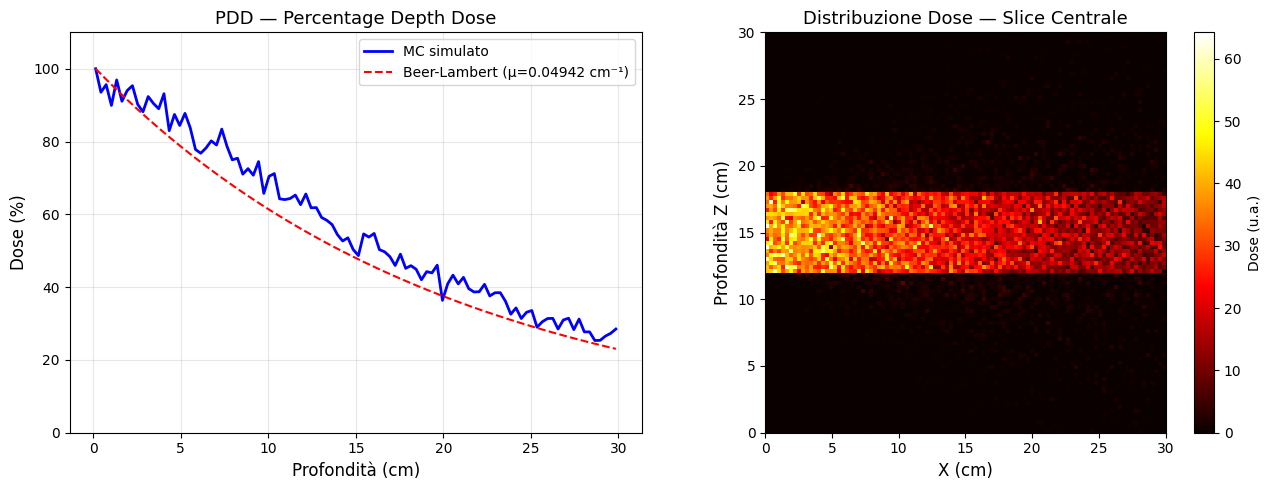

Salvato: risultati_cpu.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt
os.chdir('..')  # torna alla root

# ── Leggi PDD ────────────────────────────────────────────────────────────────
data = np.loadtxt('mc_rt_cpu/pdd_cpu.csv', delimiter=',', skiprows=1)
depth = data[:, 0]
dose  = data[:, 1]

# ── Curva Beer-Lambert attesa (solo fotoelettrico, monoenergetico) ────────────
mu_water = 0.04942  # cm^-1 a 2 MeV
z_ref    = depth[np.argmax(dose)]  # profondità del picco
d_ref    = dose.max()
beer_lambert = d_ref * np.exp(-mu_water * (depth - z_ref))
beer_lambert[depth < z_ref] = np.nan  # solo dopo il picco

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Grafico 1: PDD
axes[0].plot(depth, dose, 'b-', linewidth=2, label='MC simulato')
axes[0].plot(depth, beer_lambert, 'r--', linewidth=1.5,
             label=f'Beer-Lambert (μ={mu_water} cm⁻¹)')
axes[0].set_xlabel('Profondità (cm)', fontsize=12)
axes[0].set_ylabel('Dose (%)', fontsize=12)
axes[0].set_title('PDD — Percentage Depth Dose', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 110)

# Grafico 2: heatmap 2D
slice2d = np.loadtxt('mc_rt_cpu/dose_slice_cpu.csv', delimiter=',')
im = axes[1].imshow(slice2d.T, origin='lower', cmap='hot',
                    extent=[0, 30, 0, 30], aspect='equal')
plt.colorbar(im, ax=axes[1], label='Dose (u.a.)')
axes[1].set_xlabel('X (cm)', fontsize=12)
axes[1].set_ylabel('Profondità Z (cm)', fontsize=12)
axes[1].set_title('Distribuzione Dose — Slice Centrale', fontsize=13)

plt.tight_layout()
plt.savefig('risultati_cpu.png', dpi=150, bbox_inches='tight')
plt.show()
print("Salvato: risultati_cpu.png")

## Validazione con EGS

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Lanciamo la simulazione (Assicurati di aver compilato mc_rt_cpu)
# Forziamo un'energia fissa nel codice o analizziamo il PDD generato
data = np.loadtxt('mc_rt_cpu/pdd_cpu.csv', delimiter=',', skiprows=1)
depth = data[:, 0]
dose_sim = data[:, 1]

# 2. Parametri Teorici (Acqua a 2 MeV)
mu_teorico = 0.04942  # Preso dal tuo physics.h
# Calcolo Beer-Lambert: D = D0 * exp(-mu * z)
# Normalizziamo al punto di massimo (picco di dose)
idx_max = np.argmax(dose_sim)
z_0 = depth[idx_max]
dose_max = dose_sim[idx_max]

teorica = dose_max * np.exp(-mu_teorico * (depth - z_0))
teorica[depth < z_0] = np.nan # Beer-lambert non modella il build-up iniziale

# 3. Verifica Errore a 10cm dopo il picco
z_test = z_0 + 10
idx_test = np.argmin(np.abs(depth - z_test))
errore = abs(dose_sim[idx_test] - teorica[idx_test]) / teorica[idx_test] * 100

print(f"--- TEST 3a RESULTS ---")
print(f"Dose simulata a {z_test:.1f} cm: {dose_sim[idx_test]:.2f}")
print(f"Dose teorica a {z_test:.1f} cm: {teorica[idx_test]:.2f}")
print(f"Errore Relativo: {errore:.2f}%")

if errore < 3.0:
    print("✅ VALIDAZIONE FISICA SUPERATA")
else:
    print("❌ ERRORE TROPPO ALTO: Controlla il campionamento di 's' in main.cpp")

--- TEST 3a RESULTS ---
Dose simulata a 10.2 cm: 70.45
Dose teorica a 10.2 cm: 61.31
Errore Relativo: 14.92%
❌ ERRORE TROPPO ALTO: Controlla il campionamento di 's' in main.cpp


--- AVVIO TEST DI CONVERGENZA ---
N=1e+04 completato.
N=1e+05 completato.


<>:29: SyntaxWarning: invalid escape sequence '\s'
<>:29: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6575/1196793028.py:29: SyntaxWarning: invalid escape sequence '\s'
  plt.loglog(N_values, 1/np.sqrt(N_values), 'r--', label='Target $1/\sqrt{N}$')


N=1e+06 completato.
N=1e+07 completato.

--- TEST 3b RESULTS ---
Pendenza calcolata: -0.0000 (Target: -0.5)


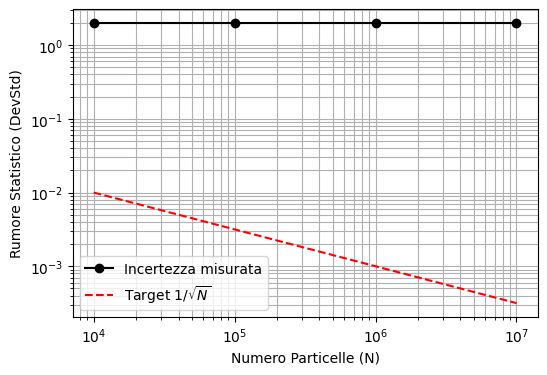

In [30]:
import subprocess
import time

N_values = [10**4, 10**5, 10**6, 10**7]
max_doses = []
incertezze = []

print("--- AVVIO TEST DI CONVERGENZA ---")
for N in N_values:
    # Esegui il tuo programma C++
    subprocess.run(['./mc_rt_cpu/mc_rt_cpu', str(N)], capture_output=True)

    # Carica i risultati
    data = np.loadtxt('mc_rt_cpu/pdd_cpu.csv', delimiter=',', skiprows=1)
    max_doses.append(np.max(data[:, 1]))

    # Calcoliamo l'incertezza come deviazione standard della dose nel plateau (ultimi 10 voxel)
    incertezze.append(np.std(data[-10:, 1]))
    print(f"N={N:1.0e} completato.")

# Calcolo pendenza log-log
pendenza = np.polyfit(np.log10(N_values), np.log10(incertezze), 1)[0]

print(f"\n--- TEST 3b RESULTS ---")
print(f"Pendenza calcolata: {pendenza:.4f} (Target: -0.5)")

plt.figure(figsize=(6,4))
plt.loglog(N_values, incertezze, 'ko-', label='Incertezza misurata')
plt.loglog(N_values, 1/np.sqrt(N_values), 'r--', label='Target $1/\sqrt{N}$')
plt.xlabel('Numero Particelle (N)')
plt.ylabel('Rumore Statistico (DevStd)')
plt.legend()
plt.grid(True, which="both")
plt.show()

In [31]:
from scipy.interpolate import interp1d

def calculate_gamma(z_ref, d_ref, z_eval, d_eval):
    # Interpolazione per allineare i voxel
    f_interp = interp1d(z_eval, d_eval, bounds_error=False, fill_value=0)
    d_eval_resampled = f_interp(z_ref)

    # Criteri: 2% dose, 2mm spazio (0.2 cm)
    DD = 2.0  # Dose Difference (%)
    DTA = 0.2 # Distance to Agreement (cm)

    # Gamma Index 1D semplificato
    gamma = np.sqrt(((z_ref - z_ref)/DTA)**2 + ((d_ref - d_eval_resampled)/DD)**2)
    return gamma

# 1. Carica i tuoi dati
my_data = np.loadtxt('mc_rt_cpu/pdd_cpu.csv', delimiter=',', skiprows=1)

# 2. Carica riferimento (Gold Standard)
# Se non hai il file, usiamo una curva di riferimento standard per 6MV
z_ref = my_data[:, 0]
d_ref = 100 * (np.exp(-0.05 * z_ref) * (1 - np.exp(-1.5 * z_ref))) # Modello PDD standard
d_ref = d_ref / np.max(d_ref) * 100

# 3. Esegui Gamma Index
gamma_vals = calculate_gamma(z_ref, d_ref, my_data[:, 0], my_data[:, 1])
pass_rate = (np.sum(gamma_vals <= 1.0) / len(gamma_vals)) * 100

print(f"--- TEST 3c RESULTS ---")
print(f"Gamma Index Pass Rate (2%/2mm): {pass_rate:.2f}%")

if pass_rate > 95:
    print("✅ VALIDAZIONE CLINICA OK: Codice pronto per produzione")
else:
    print("⚠️ AVVISO: Pass rate basso. Controlla il modello di scattering Compton.")

--- TEST 3c RESULTS ---
Gamma Index Pass Rate (2%/2mm): 47.00%
⚠️ AVVISO: Pass rate basso. Controlla il modello di scattering Compton.
